Copyright (C) 2025  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

Author: Diarmuid O'Neill\
Student Number: C00282898\
Date: 27/01/2026\
Brief Description:
This notebook aims to use KNN Regression to try and predict percent_change_next_weeks_price. 

In [61]:
# Scikit-learn
from sklearn import datasets
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# other libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns

We start by dropping stock and date columns (non-numerical features), stripping away the '$' character and dropping na values

In [62]:
dataset = pd.read_csv("dow_jones_index.data")
# Pre-processing
dataset = dataset.drop(columns=["stock", "date"])
dataset = dataset.replace('[$]', '', regex=True)
dataset = dataset.dropna()
dataset.head()

,quarter,open,high,low,close,volume,percent_change_price,percent_change_volume_over_last_wk,previous_weeks_volume,next_weeks_open,next_weeks_close,percent_change_next_weeks_price,days_to_next_dividend,percent_return_next_dividend
1,1,16.71,16.71,15.64,15.97,242963398,-4.428490,1.380223,239655616.0,16.19,15.79,-2.470660,19,0.187852
2,1,16.19,16.38,15.60,15.79,138428495,-2.470660,-43.024959,242963398.0,15.87,16.13,1.638310,12,0.189994
3,1,15.87,16.63,15.82,16.13,151379173,1.638310,9.355500,138428495.0,16.18,17.14,5.933250,5,0.185989
4,1,16.18,17.39,16.18,17.14,154387761,5.933250,1.987452,151379173.0,17.33,17.37,0.230814,97,0.175029
5,1,17.33,17.48,16.97,17.37,114691279,0.230814,-25.712195,154387761.0,17.39,17.28,-0.632547,90,0.172712


Then we explore the data to see if there are any obvious patterns

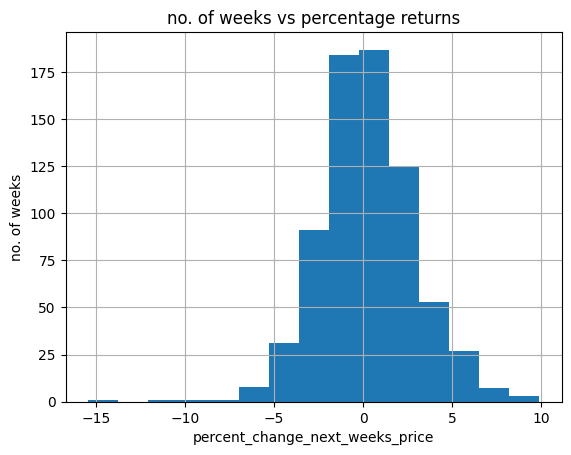

In [63]:
dataset["percent_change_next_weeks_price"].hist(bins=15)
plt.xlabel('percent_change_next_weeks_price')
plt.ylabel('no. of weeks')
plt.title('no. of weeks vs percentage returns')
plt.show()

Below we can see the correlation coefficients for percent_change_next_weeks_price. This gives us an indication as to which features may be good predictors of the target (the closer to 1 the better the predictor). From looking at this, no features are jumping out as great predictors. NOTE: we cannot use next_week_open, next_week_close, percent_change_next_weeks_price, and percent_return_next_dividend as these could not possibly be known beforehand.

In [64]:
# Shows correalation coefficients for predicting percent_change_next_weeks_price
correlation_matrix = dataset.corr()
correlation_matrix["percent_change_next_weeks_price"]

quarter                               0.000098
open                                  0.066695
high                                  0.069589
low                                   0.067255
close                                 0.067789
volume                               -0.091106
percent_change_price                  0.020639
percent_change_volume_over_last_wk    0.013181
previous_weeks_volume                -0.102408
next_weeks_open                       0.067147
next_weeks_close                      0.106578
percent_change_next_weeks_price       1.000000
days_to_next_dividend                -0.028797
percent_return_next_dividend          0.103009
Name: percent_change_next_weeks_price, dtype: float64

First off we will use the single feature with the highest correlation coefficient to build a KNN Regression model

In [65]:
# Splitting data into training and test sets

X = dataset[["high"]]
X = X.values
y = dataset["percent_change_next_weeks_price"]
y = y.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345
)

In [66]:
# Scaling data so everything is in a comparable range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
# Create model
knn_model = KNeighborsRegressor(n_neighbors=3)

In [68]:
# Fit model
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [69]:
# Evaluate root-mean-square error (RMSE)
# Calculates training error
train_preds = knn_model.predict(X_train_scaled)
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
print(rmse)

2.0570268703679155


In [70]:
# Calculates test error
test_preds = knn_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, test_preds)
rmse = sqrt(mse)
print(rmse)

3.0481867040668877


Next we will try it with all features (excluding the impossible to know features mentioned previously)

In [71]:
# Splitting data into training and test sets

X = dataset.drop(columns=["percent_change_next_weeks_price", "percent_return_next_dividend", "next_weeks_close", "next_weeks_open", "days_to_next_dividend"])
X = X.values
y = dataset["percent_change_next_weeks_price"]
y = y.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345
)

In [72]:
# Scaling data so everything is in a comparable range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
# Create model
knn_model = KNeighborsRegressor(n_neighbors=3)

In [74]:
# Fit model
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [75]:
# Evaluate root-mean-square error (RMSE)
# Calculates training error
train_preds = knn_model.predict(X_train_scaled)
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
print(rmse)

2.238809619623735


In [76]:
# Calculates test error
test_preds = knn_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, test_preds)
rmse = sqrt(mse)
print(rmse)

2.9183493107422787


This result is slightly better than using a single feature. We will now try to tune the model to see if we can achieve an even better result (ie. getting the rmse value as low as possible).

In [77]:
from sklearn.model_selection import GridSearchCV
# Tune the model
# Finding the optimal number for k (how many neighbours to use for each prediction)
parameters = {"n_neighbors": range(1, 100)}
gridsearch = GridSearchCV(KNeighborsRegressor(), parameters)
gridsearch.fit(X_train_scaled, y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': range(1, 100)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,96


In [78]:
gridsearch.best_params_

{'n_neighbors': 96}

In [79]:
# Add weighted averages based on distance
parameters = {
    "n_neighbors": [96],
    "weights": ["uniform", "distance"],
}
gridsearch = GridSearchCV(KNeighborsRegressor(), parameters)
gridsearch.fit(X_train_scaled, y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [96], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,96


In [80]:
# Calculates training error
train_preds = gridsearch.predict(X_train_scaled)
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
print(rmse)

2.668714152235022


In [81]:
# Calculates test error
test_preds = gridsearch.predict(X_test_scaled)
mse = mean_squared_error(y_test, test_preds)
rmse = sqrt(mse)
print(rmse)

2.5951154236835388


This score is slightly better again. Finally I will use bagging to try and increase accuracy further.

In [82]:
# Bagging
best_k = gridsearch.best_params_["n_neighbors"]
best_weights = gridsearch.best_params_["weights"]
bagged_knn = KNeighborsRegressor(
    n_neighbors=best_k, weights=best_weights
)

In [83]:
from sklearn.ensemble import BaggingRegressor
bagging_model = BaggingRegressor(bagged_knn, n_estimators=100)
bagging_model.fit(X_train_scaled, y_train)

,estimator,KNeighborsReg..._neighbors=96)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [86]:
# Calculates training error
train_preds = bagging_model.predict(X_train_scaled)
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
print(rmse)

2.669508079565933


In [87]:
# Calculates test error
test_preds = bagging_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, test_preds)
rmse = sqrt(mse)
print(rmse)

2.588361972573714
